installing planet profile

In [ ]:
# ==========================================================
# Installs PlanetProfile and forces a runtime restart at the end.
# ==========================================================

get_ipython().system('pip install -q PlanetProfile sqlalchemy')

import os
os.kill(os.getpid(), 9)


creating ionic molal conductivities splines using b-spline fitting
temperature and square root of ionic strength are used as x and y axes in this version

KCl: 42 points at 0.1 MPa, molality 0.0001-1.0000 mol/kg, I 0.0001-1.0000 mol/kg
NaCl: 42 points at 0.1 MPa, molality 0.0001-0.9999 mol/kg, I 0.0001-0.9999 mol/kg
MgCl2: 35 points at 0.1 MPa, molality 0.0001-0.3609 mol/kg, I 0.0004-1.0827 mol/kg
Na2SO4: 42 points at 0.1 MPa, molality 0.0001-0.4999 mol/kg, I 0.0003-1.4997 mol/kg
K2SO4: 42 points at 0.1 MPa, molality 0.0001-0.4783 mol/kg, I 0.0003-1.4349 mol/kg
  [PHYSICS WARNING for K+ (from KCl)]: Model boundaries violated inside hull:
    - 208 points have d2I < 0
K+ (from KCl): interpolant built on 42 points [grid (RectBivariateSpline)], s=32.8, training rel. RMSE=5.910e-03, T 278.1-363.1 K, I 0.0001-1.0000 mol/kg
  [PHYSICS WARNING for Cl- (from KCl)]: Model boundaries violated inside hull:
    - 214 points have d2I < 0
Cl- (from KCl): interpolant built on 42 points [grid (RectBivariateSpline)], s=32.8, training rel. RMSE=5.985e-03, T 278.1-363.1 K, I 0.0001-1.0000 mol/kg
  [PHYSICS WARNING for Na+ (from NaCl)]: Model boundaries vio

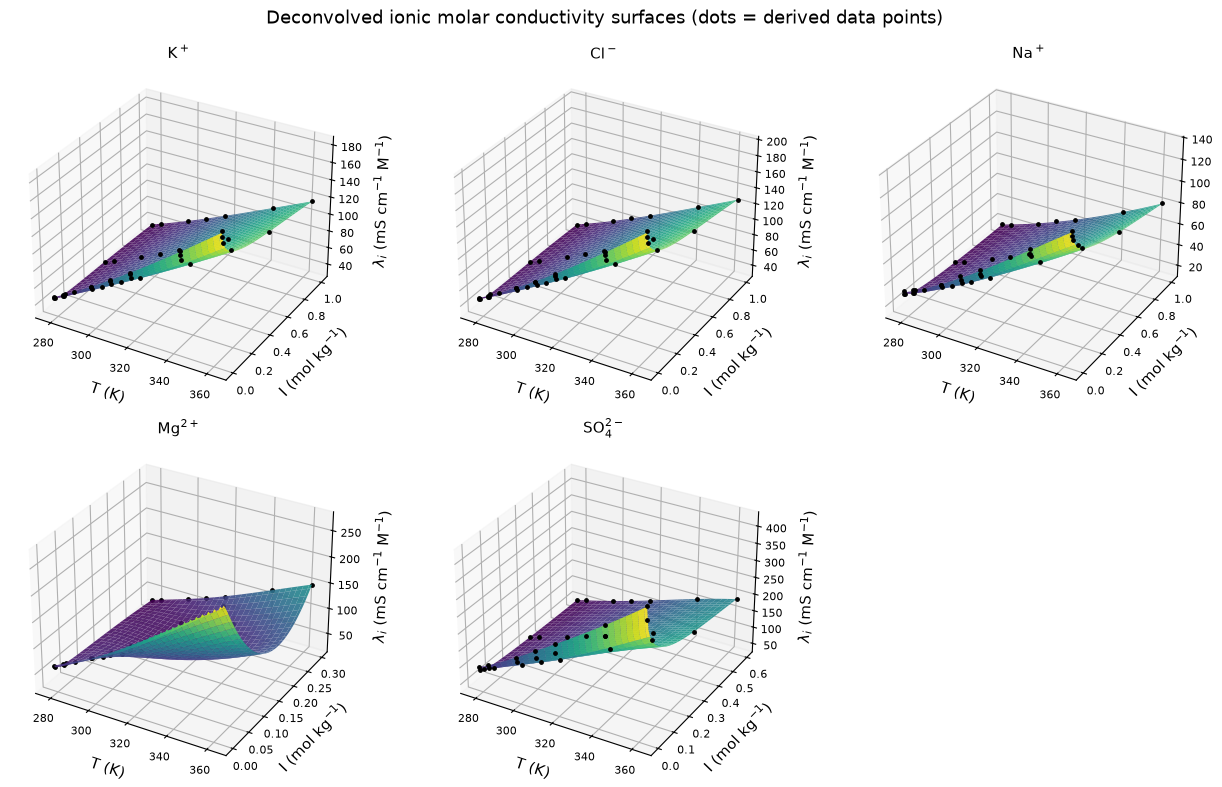

  saved Figures/ion_surface_Kplus.pdf and Figures/ion_surface_Kplus.png
  saved Figures/ion_surface_Clminus.pdf and Figures/ion_surface_Clminus.png
  saved Figures/ion_surface_Naplus.pdf and Figures/ion_surface_Naplus.png
  saved Figures/ion_surface_Mg2plus.pdf and Figures/ion_surface_Mg2plus.png
  saved Figures/ion_surface_SO42minus.pdf and Figures/ion_surface_SO42minus.png

Cell 1 done. Molar Ion splines available: spline_k, spline_cl, spline_na, spline_mg, spline_so4
  K$^+$        native range: T 278.1-363.1 K, I 0.0001-1.0000 mol/kg
  Cl$^-$       native range: T 278.1-363.1 K, I 0.0001-1.0000 mol/kg
  Na$^+$       native range: T 278.1-363.1 K, I 0.0001-0.9999 mol/kg
  Mg$^{2+}$    native range: T 278.1-363.1 K, I 0.0004-0.2983 mol/kg
  SO$_4^{2-}$  native range: T 278.1-363.1 K, I 0.0003-0.5967 mol/kg


In [ ]:
# ==========================================================
# CELL 1 - THE MODEL
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import SmoothBivariateSpline, RectBivariateSpline
from scipy.spatial import Delaunay

FIG_DIR = 'Figures'
os.makedirs(FIG_DIR, exist_ok=True)

SQRT_I = True  # GLOBAL SWITCH: fit splines against sqrt(I) instead of raw I

MIN_POINTS = 16
REFERENCE_PRESSURE_MPA = 0.1

plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'figure.dpi': 100,
    'savefig.bbox': 'tight',
})


def save_fig(fig, name):
    """Save a figure as both vector PDF (for Overleaf) and 300dpi PNG (for quick preview)."""
    pdf_path = os.path.join(FIG_DIR, f'{name}.pdf')
    png_path = os.path.join(FIG_DIR, f'{name}.png')
    fig.savefig(pdf_path)
    fig.savefig(png_path, dpi=300)
    print(f"  saved {pdf_path} and {png_path}")


# ==========================================
# 0. SPLINE WRAPPER (cubic B-spline, grid-aware)
# ==========================================

class IonSpline:
    """
    Replaces CloughTocher2DInterpolator with a cubic (kx=ky=3) tensor-product
    B-spline, while keeping the same .ev(t, I) / .ev_or_nan(t, I) interface.
    Includes built-in validation of thermodynamic and physical limits.
    """

    def __init__(self, t, I, lambda_val, label, s=None, kx=3, ky=3, grid_decimals=6):
        self.label = label
        t = np.asarray(t, dtype=float)
        I = np.asarray(I, dtype=float)
        lambda_val = np.asarray(lambda_val, dtype=float)

        n_t, n_I = len(np.unique(t)), len(np.unique(I))
        if n_t < kx + 1 or n_I < ky + 1:
            raise ValueError(
                f"{label}: a bidegree-{kx} spline needs >= {kx + 1} distinct T values "
                f"and >= {ky + 1} distinct I values; got {n_t} T levels, {n_I} I levels."
            )

        m = len(t)
        s_used = (m - np.sqrt(2 * m)) if s is None else s
        self.s_used = s_used

        grid = self._try_grid(t, I, lambda_val, grid_decimals)
        try:
            if grid is not None:
                Tg, Ig, Z = grid
                X_g = np.sqrt(Ig) if SQRT_I else Ig
                self._spline = RectBivariateSpline(Tg, X_g, Z, kx=kx, ky=ky, s=s_used)
                self.method = 'grid (RectBivariateSpline)'
            else:
                X_scatter = np.sqrt(I) if SQRT_I else I
                self._spline = SmoothBivariateSpline(t, X_scatter, lambda_val, kx=kx, ky=ky, s=s_used)
                self.method = 'scattered (SmoothBivariateSpline)'
        except Exception as e:
            raise RuntimeError(
                f"{label}: bicubic spline fit failed (s={s_used}, method attempt="
                f"{'grid' if grid is not None else 'scattered'}): {e}. "
                f"Try raising s, or check for near-duplicate/near-collinear (T, I) points."
            )

        # CRITICAL FIX: Build the hull in the same coordinate space used by the spline fit
        self._hull = Delaunay(np.column_stack([t, self._x(I)]))
        self.t_range = (float(t.min()), float(t.max()))
        self.I_range = (float(I.min()), float(I.max()))

        # Post-fit physical assumption check
        self.validate_physics()

    @staticmethod
    def _try_grid(t, I, lam, decimals):
        df = pd.DataFrame({'t': np.round(t, decimals), 'I': np.round(I, decimals), 'lam': lam})
        df = df.drop_duplicates(subset=['t', 'I'])
        if len(df) < 2: return None
        piv = df.pivot(index='t', columns='I', values='lam')
        if piv.isna().any().any(): return None
        return piv.index.values, piv.columns.values, piv.values

    def _in_hull(self, t_query, I_query):
        # CRITICAL FIX: Query the hull using transformed coordinates
        return self._hull.find_simplex(np.column_stack([t_query, self._x(I_query)])) >= 0

    def _x(self, I):
        return np.sqrt(I) if SQRT_I else np.asarray(I, dtype=float)

    def ev_or_nan(self, t_query, I_query):
        t_query, I_query = np.atleast_1d(t_query), np.atleast_1d(I_query)
        z = self._spline.ev(t_query, self._x(I_query))
        return np.where(self._in_hull(t_query, I_query), z, np.nan)

    def ev(self, t_query, I_query):
        result = self.ev_or_nan(t_query, I_query)
        if np.any(np.isnan(result)):
            raise ValueError(f"{self.label} spline: query point(s) fall outside the convex hull.")
        return result if result.size > 1 else result.item()

    def dT(self, t_query, I_query):
        t_query, I_query = np.atleast_1d(t_query), np.atleast_1d(I_query)
        z = self._spline.ev(t_query, self._x(I_query), dx=1, dy=0)
        return np.where(self._in_hull(t_query, I_query), z, np.nan)

    def dI_val(self, t_query, I_query):
        t_query, I_query = np.atleast_1d(t_query), np.atleast_1d(I_query)
        g = self._spline.ev(t_query, self._x(I_query), dx=0, dy=1)
        val = g / (2 * np.sqrt(I_query)) if SQRT_I else g
        return np.where(self._in_hull(t_query, I_query), val, np.nan)

    def d2I_val(self, t_query, I_query):
        t_query, I_query = np.atleast_1d(t_query), np.atleast_1d(I_query)
        g1 = self._spline.ev(t_query, self._x(I_query), dx=0, dy=1)
        g2 = self._spline.ev(t_query, self._x(I_query), dx=0, dy=2)
        if SQRT_I:
            u = np.sqrt(I_query)
            val = g2 / (4 * I_query) - g1 / (4 * I_query * u)
        else:
            val = g2
        return np.where(self._in_hull(t_query, I_query), val, np.nan)



    def validate_physics(self):
        """Sweeps a dense grid over the hull to check thermodynamic rules.
        I is sampled logarithmically so the low-I decades (where the
        sqrt(I) behaviour lives) are audited as densely as high I."""
        t_vals = np.linspace(self.t_range[0], self.t_range[1], 50)
        I_lo = max(1e-6, self.I_range[0])
        I_vals = np.geomspace(I_lo, self.I_range[1], 50)
        Tg, Ig = np.meshgrid(t_vals, I_vals)
        Tg_flat, Ig_flat = Tg.ravel(), Ig.ravel()

        inside = self._in_hull(Tg_flat, Ig_flat)
        Ti, Ii = Tg_flat[inside], Ig_flat[inside]

        if len(Ti) == 0: return

        lam = self.ev_or_nan(Ti, Ii)
        dT = self.dT(Ti, Ii)
        dI = self.dI_val(Ti, Ii)
        d2I = self.d2I_val(Ti, Ii)

        violations = []
        if np.any(lam < 0): violations.append(f"{(lam < 0).sum()} points have lam < 0")
        if np.any(dT < 0):  violations.append(f"{(dT < 0).sum()} points have dT < 0")
        if np.any(dI > 0):  violations.append(f"{(dI > 0).sum()} points have dI > 0")
        if np.any(d2I < 0): violations.append(f"{(d2I < 0).sum()} points have d2I < 0")

        if violations:
            print(f"  [PHYSICS WARNING for {self.label}]: Model boundaries violated inside hull:")
            for v in violations:
                print(f"    - {v}")




# ==========================================
# 0.5 ION CONDUCTIVITY MODEL
# ==========================================

class IonConductivityModel:
    SALT_STOICHIOMETRY = {
        'KCl':    {'K': 1, 'Cl': 1},
        'NaCl':   {'Na': 1, 'Cl': 1},
        'MgCl2':  {'Mg': 1, 'Cl': 2},
        'Na2SO4': {'Na': 2, 'SO4': 1},
        'K2SO4':  {'K': 2, 'SO4': 1},
    }

    def __init__(self):
        self.splines = {}

    def add_ion(self, ion_name, spline):
        self.splines[ion_name] = spline
        return spline

    def ion(self, ion_name):
        if ion_name not in self.splines:
            raise KeyError(f"No fitted spline for ion '{ion_name}' yet. "
                           f"Available: {list(self.splines)}")
        return self.splines[ion_name]

    def stoich_for(self, salt_name):
        if salt_name not in self.SALT_STOICHIOMETRY:
            raise ValueError(f"Unknown salt '{salt_name}'. Known salts: {list(self.SALT_STOICHIOMETRY)}")
        return self.SALT_STOICHIOMETRY[salt_name]

    def predict(self, salt_name, T_K, molality, allow_extrapolation_nan=True):
        stoich = self.stoich_for(salt_name)
        T_K = np.atleast_1d(np.asarray(T_K, dtype=float))
        molality = np.atleast_1d(np.asarray(molality, dtype=float))
        I = molality * get_ionic_strength_factor(salt_name)

        total = np.zeros_like(T_K, dtype=float)
        for ion_name, nu in stoich.items():
            spline = self.ion(ion_name)
            eval_fn = spline.ev_or_nan if allow_extrapolation_nan else spline.ev
            lam = eval_fn(T_K, I)
            total = total + nu * molality * lam
        return total if total.size > 1 else total.item()


# ==========================================
# 1. LOAD DATA
# ==========================================

df = pd.read_csv('empirical_conductivity_library.csv')

required_cols = {'Salt', 'Temperature_C', 'Molality_molkg', 'Conductivity_mScm', 'Pressure_MPa'}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"CSV is missing required columns: {missing}")

ALL_SALTS = ['KCl', 'NaCl', 'MgCl2', 'Na2SO4', 'K2SO4']


def get_ionic_strength_factor(salt_name):
    if salt_name in ['KCl', 'NaCl']:
        return 1.0
    elif salt_name in ['MgCl2', 'Na2SO4', 'K2SO4']:
        return 3.0
    else:
        raise ValueError(f"Unknown salt logic for {salt_name}")


salt_dfs = {}
for salt in ALL_SALTS:
    d = df[df['Salt'] == salt].copy()
    if d.empty:
        raise ValueError(f"No rows found for salt '{salt}'. Check CSV.")

    at_reference_pressure = d['Pressure_MPa'] == REFERENCE_PRESSURE_MPA
    d = d[at_reference_pressure].copy()
    if d.empty:
        raise ValueError(f"{salt} has no rows at reference pressure.")

    missing_molality_mask = d['Molality_molkg'].isna()
    d = d[~missing_molality_mask].copy()
    if d.empty:
        raise ValueError(f"{salt} has no usable rows left.")

    d = d.rename(columns={'Molality_molkg': 'Molality', 'Temperature_C': 'Temperature',
                           'Conductivity_mScm': 'Conductivity'})
    d['temp_K'] = d['Temperature'] + 273.15
    d['I'] = d['Molality'] * get_ionic_strength_factor(salt)

    salt_dfs[salt] = d
    print(f"{salt}: {len(d)} points at {REFERENCE_PRESSURE_MPA} MPa, "
          f"molality {d['Molality'].min():.4f}-{d['Molality'].max():.4f} mol/kg, "
          f"I {d['I'].min():.4f}-{d['I'].max():.4f} mol/kg")


# ==========================================
# 2. TRANSPORT NUMBER FUNCTION
# ==========================================

def calculate_t_kcl(temp_C, molality):
    term1 = (9.04e-7 * (temp_C ** 2)) - (0.000235 * temp_C) + 0.4960
    sqrt_m = np.sqrt(molality)
    term2 = 0.0027 * (sqrt_m / (1.0 + 0.05 * sqrt_m))
    return term1 - term2


# ==========================================
# 3. HELPERS
# ==========================================

def fit_lambda_spline(d, label, t_col='temp_K', I_col='I', lambda_col='Lambda', s=None):
    d = d.copy()
    d = d.drop_duplicates(subset=[t_col, I_col])
    if len(d) < MIN_POINTS:
        raise ValueError(f"{label} has too few points ({len(d)}) for a usable bicubic spline surface.")

    spline = IonSpline(d[t_col].values, d[I_col].values, d[lambda_col].values, label, s=s)

    fitted = spline.ev(d[t_col].values, d[I_col].values)
    rel_rmse = np.sqrt(np.mean((d[lambda_col].values - fitted) ** 2)) / d[lambda_col].mean()
    print(f"{label}: interpolant built on {len(d)} points [{spline.method}], "
          f"s={spline.s_used:.3g}, training rel. RMSE={rel_rmse:.3e}, "
          f"T {spline.t_range[0]:.1f}-{spline.t_range[1]:.1f} K, "
          f"I {spline.I_range[0]:.4f}-{spline.I_range[1]:.4f} mol/kg")
    return spline, spline.t_range, spline.I_range, d


def subtract_ion_molar(source_df, salt_name, known_ion, model, new_ion_pretty_label=None):
    stoich = model.stoich_for(salt_name)
    if known_ion not in stoich:
        raise ValueError(f"{salt_name} stoichiometry {stoich} has no ion '{known_ion}'.")
    unknown_ions = [ion for ion in stoich if ion != known_ion]
    if len(unknown_ions) != 1:
        raise ValueError(f"subtract_ion_molar only supports two-ion salts; {salt_name} stoichiometry is {stoich}.")
    new_ion = unknown_ions[0]
    ion_stoich = stoich[known_ion]
    new_ion_stoich = stoich[new_ion]
    new_ion_label = new_ion_pretty_label or f"{new_ion} (from {salt_name})"

    ion_spline = model.ion(known_ion)

    I_vals = source_df['I'].values
    t_vals = source_df['temp_K'].values
    m_salt = source_df['Molality'].values

    lambda_known = ion_spline.ev_or_nan(t_vals, I_vals)
    in_hull = ~np.isnan(lambda_known)
    n_out = (~in_hull).sum()
    if n_out > 0:
        print(f"NOTE: {salt_name} -> {new_ion_label}: {n_out}/{len(source_df)} points fall outside "
              f"the {known_ion} spline's convex hull at solution I. Excluded.")

    kappa_salt = source_df['Conductivity'].values[in_hull]
    m_scaled = m_salt[in_hull]

    kappa_residual = kappa_salt - (ion_stoich * m_scaled * lambda_known[in_hull])
    lambda_new = kappa_residual / (new_ion_stoich * m_scaled)

    t_kept = t_vals[in_hull]
    I_kept = I_vals[in_hull]
    m_kept = m_scaled

    pos = lambda_new > 0
    if (~pos).any():
        print(f"WARNING: {(~pos).sum()} {new_ion_label} points are non-positive. Dropped.")

    ion_df = pd.DataFrame({'temp_K': t_kept[pos], 'I': I_kept[pos], 'Molality': m_kept[pos], 'Lambda': lambda_new[pos]})
    spline, t_range, I_range, ion_df = fit_lambda_spline(ion_df, new_ion_label)
    model.add_ion(new_ion, spline)
    return spline, t_range, I_range, ion_df


# ==========================================
# 4. STEP 1: KCl -> K+ and Cl-
# ==========================================

df_kcl = salt_dfs['KCl'].copy()
df_kcl['Lambda_Salt'] = df_kcl['Conductivity'] / df_kcl['Molality']

t_plus = calculate_t_kcl(df_kcl['Temperature'].values, df_kcl['Molality'].values)
df_kcl['Lambda_K'] = t_plus * df_kcl['Lambda_Salt']
df_kcl['Lambda_Cl'] = df_kcl['Lambda_Salt'] - df_kcl['Lambda_K']

df_k_ion = pd.DataFrame({'temp_K': df_kcl['temp_K'], 'I': df_kcl['I'],
                          'Molality': df_kcl['Molality'], 'Lambda': df_kcl['Lambda_K']})
df_cl_ion = pd.DataFrame({'temp_K': df_kcl['temp_K'], 'I': df_kcl['I'],
                           'Molality': df_kcl['Molality'], 'Lambda': df_kcl['Lambda_Cl']})

model = IonConductivityModel()
spline_k,  k_t_range,  k_I_range,  df_k_ion  = fit_lambda_spline(df_k_ion,  'K+ (from KCl)')
spline_cl, cl_t_range, cl_I_range, df_cl_ion = fit_lambda_spline(df_cl_ion, 'Cl- (from KCl)')
model.add_ion('K', spline_k)
model.add_ion('Cl', spline_cl)

# ==========================================
# 5. STEP 2: NaCl -> Na+
# ==========================================
df_nacl = salt_dfs['NaCl'].copy()
spline_na, na_t_range, na_I_range, df_na_ion = subtract_ion_molar(
    df_nacl, 'NaCl', known_ion='Cl', model=model, new_ion_pretty_label='Na+ (from NaCl)')

# ==========================================
# 6. STEP 3: MgCl2 -> Mg2+
# ==========================================
df_mgcl2 = salt_dfs['MgCl2'].copy()
spline_mg, mg_t_range, mg_I_range, df_mg_ion = subtract_ion_molar(
    df_mgcl2, 'MgCl2', known_ion='Cl', model=model, new_ion_pretty_label='Mg2+ (from MgCl2)')

# ==========================================
# 7. STEP 4: Na2SO4 -> SO4 2-
# ==========================================
df_na2so4 = salt_dfs['Na2SO4'].copy()
spline_so4, so4_t_range, so4_I_range, df_so4_ion = subtract_ion_molar(
    df_na2so4, 'Na2SO4', known_ion='Na', model=model, new_ion_pretty_label='SO4 2- (from Na2SO4)')


# ==========================================
# 8. PUBLICATION FIGURE: ALL FIVE IONIC SURFACES
# ==========================================

ION_SPLINES = {
    'K$^+$':        (spline_k,  k_t_range,  k_I_range,  df_k_ion),
    'Cl$^-$':       (spline_cl, cl_t_range, cl_I_range, df_cl_ion),
    'Na$^+$':       (spline_na, na_t_range, na_I_range, df_na_ion),
    'Mg$^{2+}$':    (spline_mg, mg_t_range, mg_I_range, df_mg_ion),
    'SO$_4^{2-}$':  (spline_so4, so4_t_range, so4_I_range, df_so4_ion),
}


def plot_ion_spline(spline, t_range, I_range, ion_df, title, ax, n_points=60):
    Tg, Ig = np.meshgrid(np.linspace(t_range[0], t_range[1], n_points),
                          np.linspace(I_range[0], I_range[1], n_points))
    Z = spline.ev_or_nan(Tg.ravel(), Ig.ravel()).reshape(Tg.shape)
    surf = ax.plot_surface(Tg, Ig, Z, cmap='viridis', linewidth=0, antialiased=True, alpha=0.9)
    ax.scatter(ion_df['temp_K'], ion_df['I'], ion_df['Lambda'],
               color='black', s=6, depthshade=False)
    ax.set_title(title, pad=0)
    ax.set_xlabel('T (K)', labelpad=2)
    ax.set_ylabel('I (mol kg$^{-1}$)', labelpad=2)
    ax.set_zlabel(r'$\lambda_i$ (mS cm$^{-1}$ M$^{-1}$)', labelpad=2)
    ax.tick_params(pad=0, labelsize=8)
    return surf


print("\nGenerating ionic surface figures...")
fig = plt.figure(figsize=(13, 8))
for i, (name, (spl, tr, ir, ion_df)) in enumerate(ION_SPLINES.items(), start=1):
    ax = fig.add_subplot(2, 3, i, projection='3d')
    plot_ion_spline(spl, tr, ir, ion_df, name, ax)
fig.suptitle('Deconvolved ionic molar conductivity surfaces (dots = derived data points)', y=0.98)
fig.tight_layout()
save_fig(fig, 'ionic_surfaces')
plt.show()

for name, (spl, tr, ir, ion_df) in ION_SPLINES.items():
    safe = (name.replace('$', '').replace('^', '').replace('_', '').replace('{', '')
                .replace('}', '').replace('+', 'plus').replace('-', 'minus'))
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    plot_ion_spline(spl, tr, ir, ion_df, name, ax)
    fig.tight_layout()
    save_fig(fig, f'ion_surface_{safe}')
    plt.close(fig)

print("\nCell 1 done. Molar Ion splines available: spline_k, spline_cl, spline_na, spline_mg, spline_so4")
for name, (spl, tr, ir, _) in ION_SPLINES.items():
    print(f"  {name:12s} native range: T {tr[0]:.1f}-{tr[1]:.1f} K, I {ir[0]:.4f}-{ir[1]:.4f} mol/kg")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


validation for k2so4

=== K2SO4 held-out additivity test ===
K2SO4: 42 total reference measurements.
NOTE: 14/42 points fall outside the K+ and/or SO4 2- molar convex hulls over Ionic Strength (e.g. highest concentration levels drop out clean).
Using 28/42 points after filtering.

--- Deviation statistics ---
m > 0.01 mol/kg only (14 points):
  mean signed: +2.89%   mean abs: 2.89%   max abs: 5.61%

  Fit quality (K2SO4 reconstructed vs empirical):
    n = 28
    RMSE: 0.5841 mS/cm   MAE: 0.2968 mS/cm
    R-squared vs perfect 1:1 line: 0.9980
    Best-fit: reconstructed = 1.0374 x real + -0.0015

  Error structure diagnosis (K2SO4):
    Linear correlation: dev vs molality r=0.828 (p=0.0000)
  saved Figures/k2so4_deviation_vs_molality.pdf and Figures/k2so4_deviation_vs_molality.png


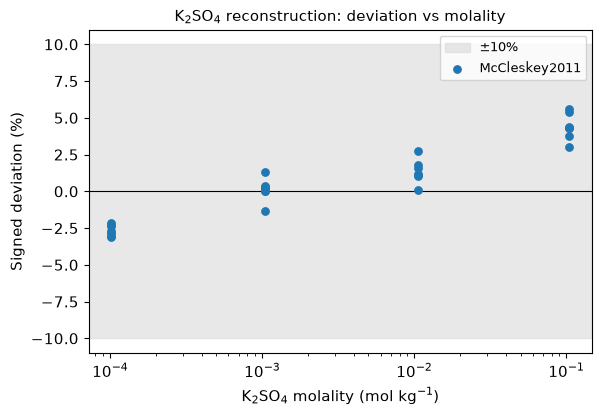

  saved Figures/k2so4_deviation_vs_temperature.pdf and Figures/k2so4_deviation_vs_temperature.png


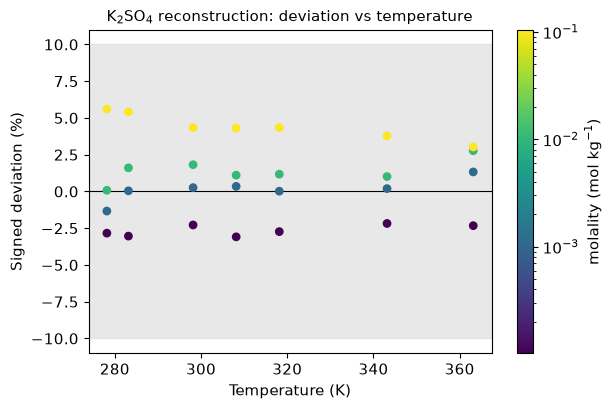

  saved Figures/k2so4_parity.pdf and Figures/k2so4_parity.png


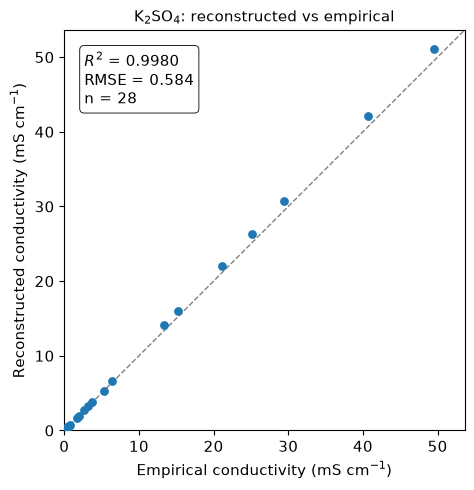

  saved Figures/k2so4_deviation_map.pdf and Figures/k2so4_deviation_map.png


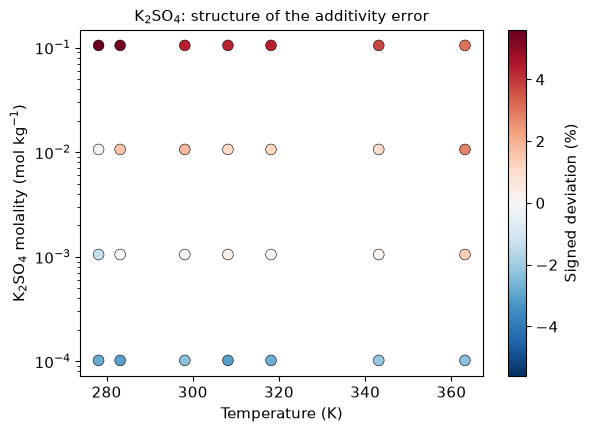

  saved Figures/k2so4_isotherms.pdf and Figures/k2so4_isotherms.png


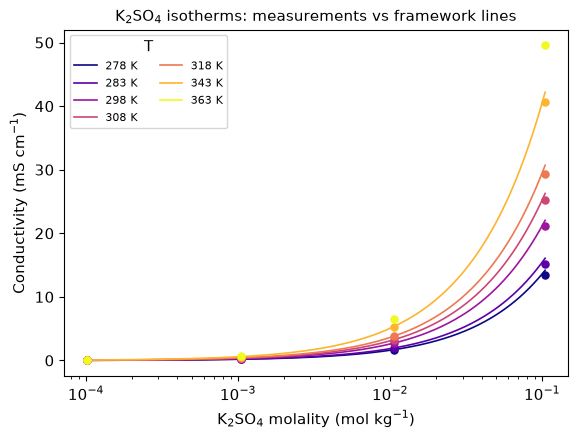

  saved Figures/k2so4_deviation_histogram.pdf and Figures/k2so4_deviation_histogram.png


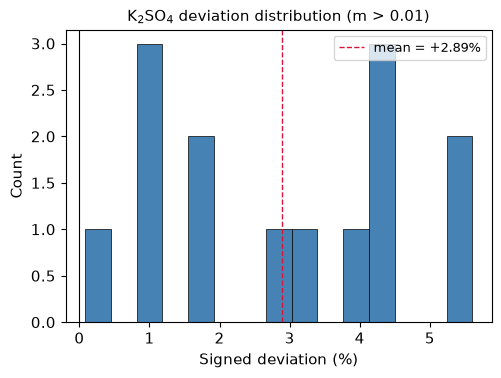

In [ ]:
# ==========================================================
# CELL 2 - K2SO4 HELD-OUT ADDITIVITY TEST
# ==========================================================

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sstats

for _name in ('salt_dfs', 'spline_k', 'spline_so4', 'k_t_range', 'k_I_range',
              'so4_t_range', 'so4_I_range', 'save_fig', 'FIG_DIR'):
    if _name not in globals():
        raise NameError(f"'{_name}' not found - run Cell 1 first.")

PCT_STABLE_MOLALITY = 0.01

# ==========================================================
# SHARED DIAGNOSTIC HELPERS
# ==========================================================

def fit_quality_stats(real, reconstructed):
    real = np.asarray(real, dtype=float)
    reconstructed = np.asarray(reconstructed, dtype=float)
    resid = reconstructed - real
    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))
    ss_res_11 = np.sum((reconstructed - real)**2)
    ss_tot = np.sum((real - real.mean())**2)
    r2_11 = 1 - ss_res_11/ss_tot if ss_tot > 0 else np.nan
    slope, intercept = np.polyfit(real, reconstructed, 1)
    return {'rmse': rmse, 'mae': mae, 'r2_vs_1to1_line': r2_11,
            'best_fit_slope': slope, 'best_fit_intercept': intercept, 'n': len(real)}

def print_fit_quality(label, real, reconstructed, units='mS/cm'):
    s = fit_quality_stats(real, reconstructed)
    print(f"\n  Fit quality ({label}):")
    print(f"    n = {s['n']}")
    print(f"    RMSE: {s['rmse']:.4f} {units}   MAE: {s['mae']:.4f} {units}")
    print(f"    R-squared vs perfect 1:1 line: {s['r2_vs_1to1_line']:.4f}")
    print(f"    Best-fit: reconstructed = {s['best_fit_slope']:.4f} x real + {s['best_fit_intercept']:.4f}")
    return s

def diagnose_error_structure(label, T_vals, M_vals, pct_dev):
    T_vals = np.asarray(T_vals, dtype=float)
    M_vals = np.asarray(M_vals, dtype=float)
    pct_dev = np.asarray(pct_dev, dtype=float)
    print(f"\n  Error structure diagnosis ({label}):")
    if len(T_vals) < 4:
        print("    Too few points for statistical breakdown.")
        return
    r_m, p_m = sstats.pearsonr(M_vals, pct_dev) if len(set(M_vals)) > 1 else (np.nan, np.nan)
    print(f"    Linear correlation: dev vs molality r={r_m:.3f} (p={p_m:.4f})")

# ==========================================================
# 1. SELECT USABLE K2SO4 POINTS (Hull filtering over environment Ionic Strength)
# ==========================================================

k2so4_real_df = salt_dfs['K2SO4'][['temp_K', 'Molality', 'I', 'Conductivity', 'Source']].copy()
n_total = len(k2so4_real_df)
print(f"=== K2SO4 held-out additivity test ===")
print(f"K2SO4: {n_total} total reference measurements.")

T_all = k2so4_real_df['temp_K'].values
M_all = k2so4_real_df['Molality'].values
I_all = k2so4_real_df['I'].values  # This is 3 * m_K2SO4

lambda_k_part = spline_k.ev_or_nan(T_all, I_all)
lambda_so4_part = spline_so4.ev_or_nan(T_all, I_all)

in_hull = ~np.isnan(lambda_k_part) & ~np.isnan(lambda_so4_part)
n_excluded = (~in_hull).sum()
if n_excluded > 0:
    print(f"NOTE: {n_excluded}/{n_total} points fall outside the K+ and/or SO4 2- molar "
          f"convex hulls over Ionic Strength (e.g. highest concentration levels drop out clean).")
if in_hull.sum() == 0:
    raise RuntimeError("No usable K2SO4 points inside the baseline ionic strength hull.")

k2so4_usable = k2so4_real_df[in_hull].reset_index(drop=True)
T_k2so4 = k2so4_usable['temp_K'].values
M_k2so4 = k2so4_usable['Molality'].values
I_k2so4 = k2so4_usable['I'].values
Z_k2so4_real = k2so4_usable['Conductivity'].values
Source_k2so4 = k2so4_usable['Source'].values

Z_yours_at_k2so4 = (2.0 * M_k2so4 * lambda_k_part[in_hull]) + (M_k2so4 * lambda_so4_part[in_hull])
n_usable = len(k2so4_usable)
print(f"Using {n_usable}/{n_total} points after filtering.")

# ==========================================================
# 2. DEVIATION METRICS
# ==========================================================
pct_dev = 100.0 * (Z_yours_at_k2so4 - Z_k2so4_real) / Z_k2so4_real
stable = M_k2so4 > PCT_STABLE_MOLALITY

print(f"\n--- Deviation statistics ---")
print(f"m > {PCT_STABLE_MOLALITY} mol/kg only ({stable.sum()} points):")
print(f"  mean signed: {np.mean(pct_dev[stable]):+.2f}%   mean abs: {np.mean(np.abs(pct_dev[stable])):.2f}%   "
      f"max abs: {np.max(np.abs(pct_dev[stable])):.2f}%")

print_fit_quality('K2SO4 reconstructed vs empirical', Z_k2so4_real, Z_yours_at_k2so4)
diagnose_error_structure('K2SO4', T_k2so4, M_k2so4, pct_dev)

# ==========================================================
# 3. DIAGNOSTIC FIGURES
# ==========================================================
unique_sources = sorted(set(Source_k2so4))
markers = ['o', 's', '^', 'D', 'v', 'P']

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.axhspan(-10, 10, color='0.85', alpha=0.6, zorder=0, label=r'$\pm$10%')
for i, src in enumerate(unique_sources):
    mask = Source_k2so4 == src
    ax.scatter(M_k2so4[mask], pct_dev[mask], s=28, marker=markers[i % len(markers)], label=src, zorder=3)
ax.axhline(0, color='black', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel(r'K$_2$SO$_4$ molality (mol kg$^{-1}$)')
ax.set_ylabel('Signed deviation (%)')
ax.set_title(r'K$_2$SO$_4$ reconstruction: deviation vs molality')
ax.legend()
save_fig(fig, 'k2so4_deviation_vs_molality')
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.axhspan(-10, 10, color='0.85', alpha=0.6, zorder=0, label=r'$\pm$10%')
sc = ax.scatter(T_k2so4, pct_dev, c=M_k2so4, cmap='viridis', s=28, zorder=3, norm=plt.matplotlib.colors.LogNorm())
plt.colorbar(sc, ax=ax, label=r'molality (mol kg$^{-1}$)')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Signed deviation (%)')
ax.set_title(r'K$_2$SO$_4$ reconstruction: deviation vs temperature')
save_fig(fig, 'k2so4_deviation_vs_temperature')
plt.show()

fig, ax = plt.subplots(figsize=(5.2, 5.2))
lims = [0, max(Z_k2so4_real.max(), Z_yours_at_k2so4.max()) * 1.05]
ax.plot(lims, lims, ls='--', color='gray', lw=1, label='1:1 Line')
for i, src in enumerate(unique_sources):
    mask = Source_k2so4 == src
    ax.scatter(Z_k2so4_real[mask], Z_yours_at_k2so4[mask], s=28, marker=markers[i % len(markers)], label=src, zorder=3)
s = fit_quality_stats(Z_k2so4_real, Z_yours_at_k2so4)
ax.text(0.05, 0.95, f"$R^2$ = {s['r2_vs_1to1_line']:.4f}\nRMSE = {s['rmse']:.3f}\nn = {s['n']}",
        transform=ax.transAxes, va='top', bbox=dict(boxstyle='round', fc='white', ec='black', lw=0.6))
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(r'Empirical conductivity (mS cm$^{-1}$)')
ax.set_ylabel(r'Reconstructed conductivity (mS cm$^{-1}$)')
ax.set_title(r'K$_2$SO$_4$: reconstructed vs empirical')
ax.set_aspect('equal')
save_fig(fig, 'k2so4_parity')
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
vmax = max(np.max(np.abs(pct_dev)), 1.0)
sc = ax.scatter(T_k2so4, M_k2so4, c=pct_dev, cmap='RdBu_r', vmin=-vmax, vmax=vmax, s=60, edgecolors='black', linewidths=0.4)
plt.colorbar(sc, ax=ax, label='Signed deviation (%)')
ax.set_yscale('log')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'K$_2$SO$_4$ molality (mol kg$^{-1}$)')
ax.set_title(r'K$_2$SO$_4$: structure of the additivity error')
save_fig(fig, 'k2so4_deviation_map')
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
temps = np.unique(np.round(T_k2so4, 1))
cmap = plt.get_cmap('plasma')
for i, tval in enumerate(temps):
    color = cmap(i / max(len(temps) - 1, 1))
    mask = np.isclose(T_k2so4, tval, atol=0.1)
    ax.scatter(M_k2so4[mask], Z_k2so4_real[mask], color=color, s=26, zorder=3)

    m_grid = np.logspace(np.log10(M_k2so4.min()), np.log10(M_k2so4.max()), 200)
    I_grid = m_grid * 3.0

    lambda_k_grid = spline_k.ev_or_nan(np.full_like(I_grid, tval), I_grid)
    lambda_so4_grid = spline_so4.ev_or_nan(np.full_like(I_grid, tval), I_grid)
    z_grid = (2.0 * m_grid * lambda_k_grid) + (m_grid * lambda_so4_grid)

    ok = ~np.isnan(z_grid)
    ax.plot(m_grid[ok], z_grid[ok], color=color, lw=1.2, label=f'{tval:.0f} K')
ax.set_xscale('log')
ax.set_xlabel(r'K$_2$SO$_4$ molality (mol kg$^{-1}$)')
ax.set_ylabel(r'Conductivity (mS cm$^{-1}$)')
ax.set_title(r'K$_2$SO$_4$ isotherms: measurements vs framework lines')
ax.legend(title='T', ncol=2, fontsize=8)
save_fig(fig, 'k2so4_isotherms')
plt.show()

fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.hist(pct_dev[stable], bins=15, color='steelblue', edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(np.mean(pct_dev[stable]), color='crimson', ls='--', lw=1, label=f'mean = {np.mean(pct_dev[stable]):+.2f}%')
ax.set_xlabel('Signed deviation (%)')
ax.set_ylabel('Count')
ax.set_title(rf'K$_2$SO$_4$ deviation distribution (m > {PCT_STABLE_MOLALITY})')
ax.legend()
save_fig(fig, 'k2so4_deviation_histogram')
plt.show()

<>:122: SyntaxWarning: invalid escape sequence '\l'
<>:127: SyntaxWarning: invalid escape sequence '\l'
<>:132: SyntaxWarning: invalid escape sequence '\l'
<>:137: SyntaxWarning: invalid escape sequence '\l'
<>:142: SyntaxWarning: invalid escape sequence '\l'
<>:122: SyntaxWarning: invalid escape sequence '\l'
<>:127: SyntaxWarning: invalid escape sequence '\l'
<>:132: SyntaxWarning: invalid escape sequence '\l'
<>:137: SyntaxWarning: invalid escape sequence '\l'
<>:142: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2396/4188424901.py:122: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$\lambda$ (>0)')
/tmp/ipykernel_2396/4188424901.py:127: SyntaxWarning: invalid escape sequence '\l'
  ax2.set_title('$d\lambda/dT$ (>0)')
/tmp/ipykernel_2396/4188424901.py:132: SyntaxWarning: invalid escape sequence '\l'
  ax3.set_title('$d\lambda/dI$ (<0)')
/tmp/ipykernel_2396/4188424901.py:137: SyntaxWarning: invalid escape sequence '\l'
  ax4.set_title('$d^2\lambda/dI^2$ (>0

=== derivative diagnostics (dense grid inside each ion hull) ===
ion  lam_min  %lam<0  %dT>0  tcoef_p1 (%/C)  tcoef_p99 (%/C)  %dI<0  %d2I>0
  K    35.67     0.0 100.00            0.88             2.65 100.00   92.27
 Cl    36.55     0.0 100.00            0.93             2.78 100.00   92.16
 Na    17.74     0.0 100.00            0.99             2.86 100.00   99.34
 Mg    30.64     0.0  97.92           -0.40             3.29  67.62   48.48
SO4    50.35     0.0 100.00            0.86             3.10 100.00   99.88
physics requires: lam>0, dT>0 (approx 1-3 %/C), dI<0, d2I>0 everywhere

=== Plotting derivative diagnostic surfaces ===


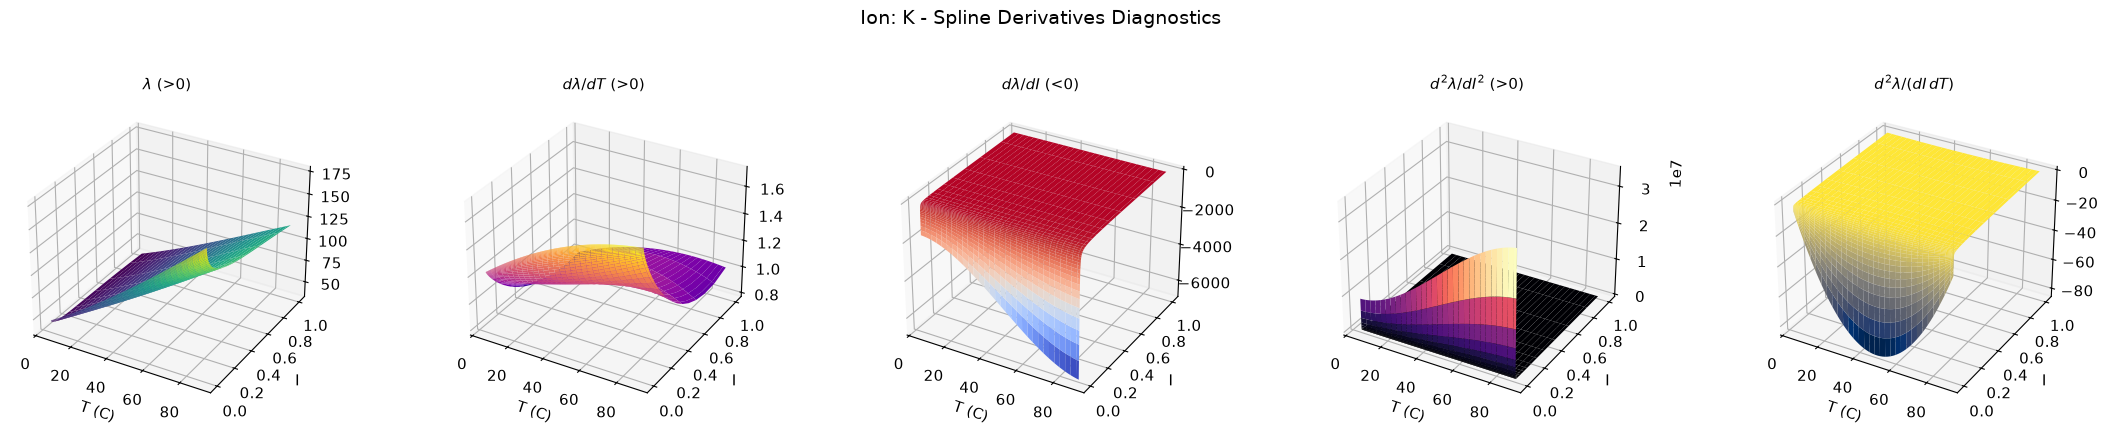

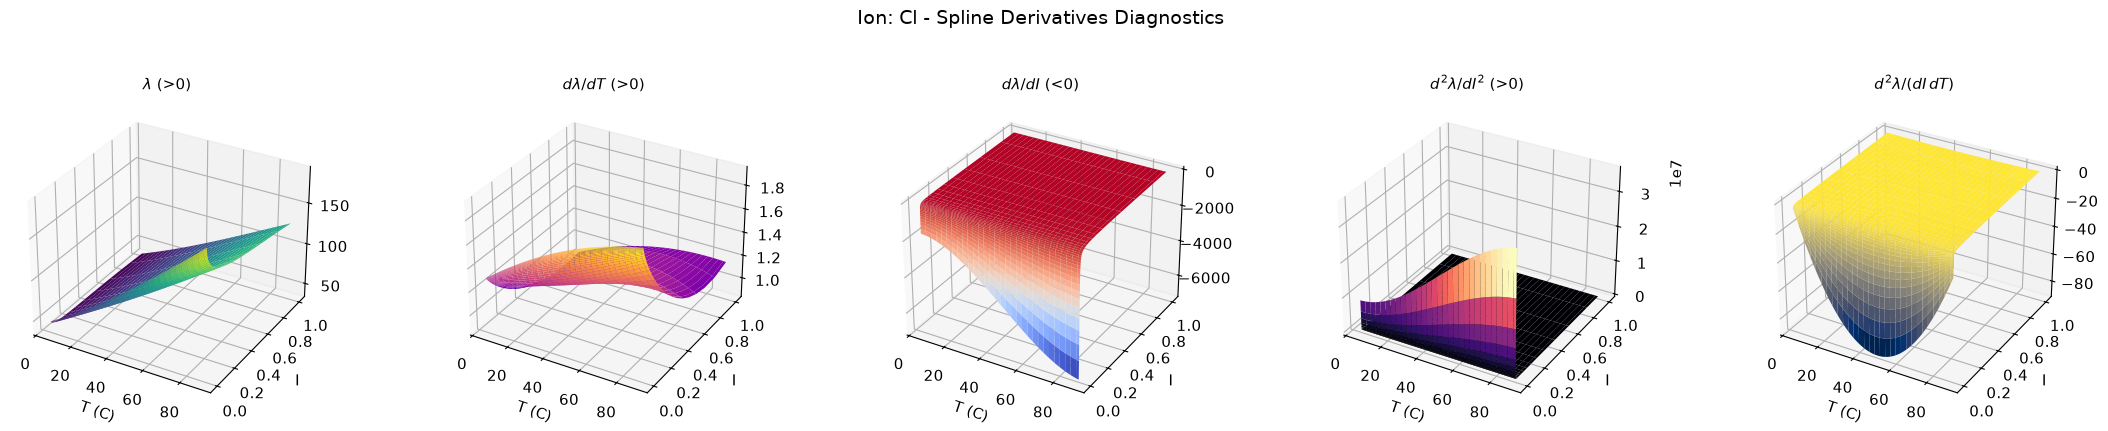

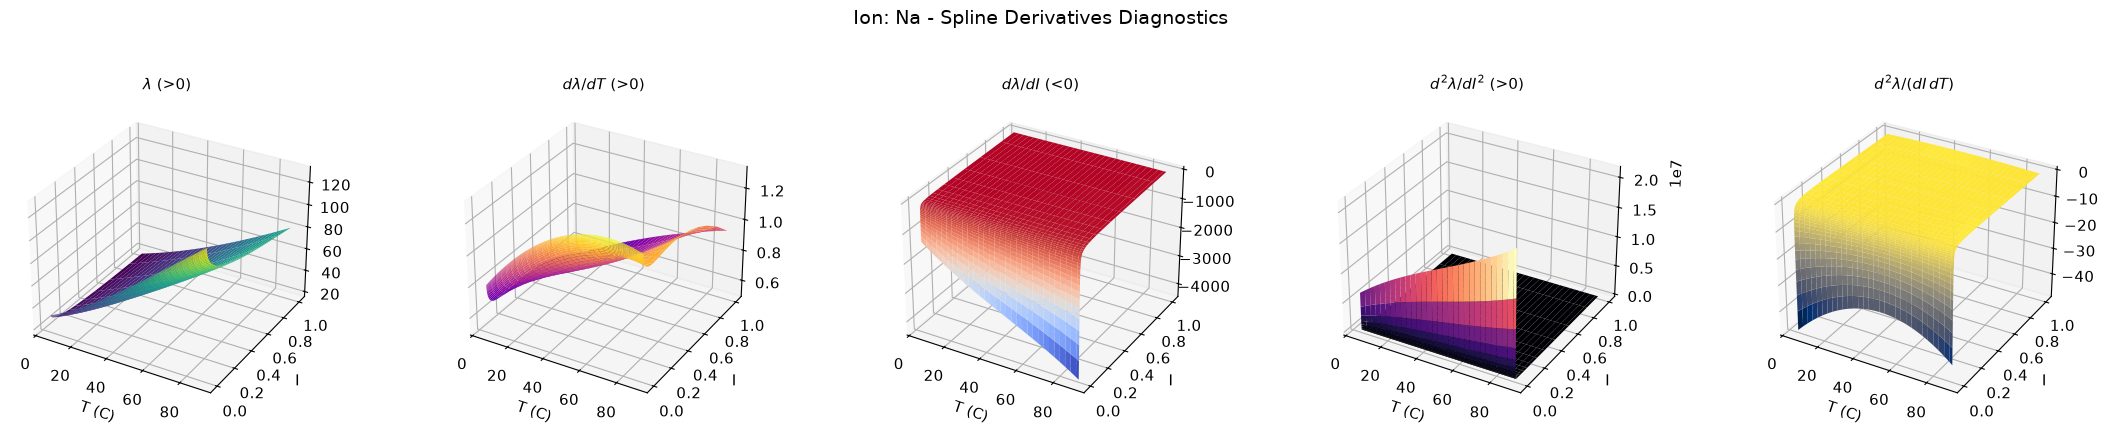

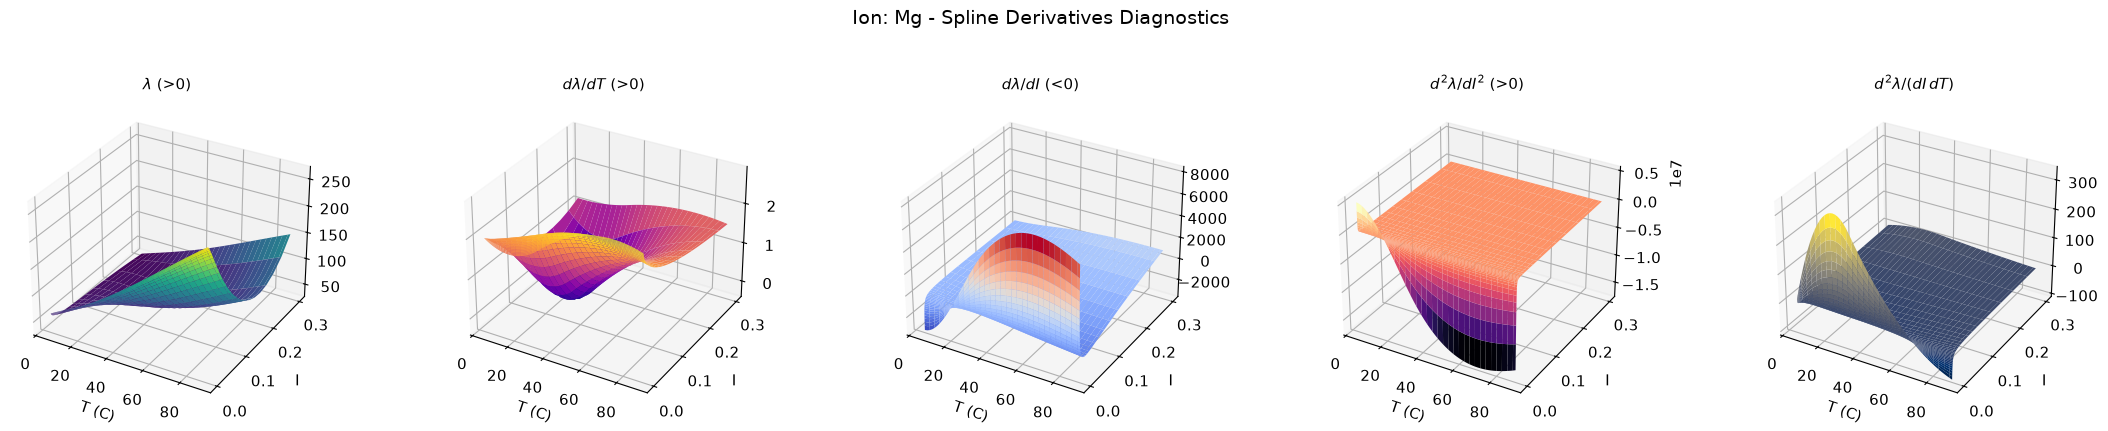

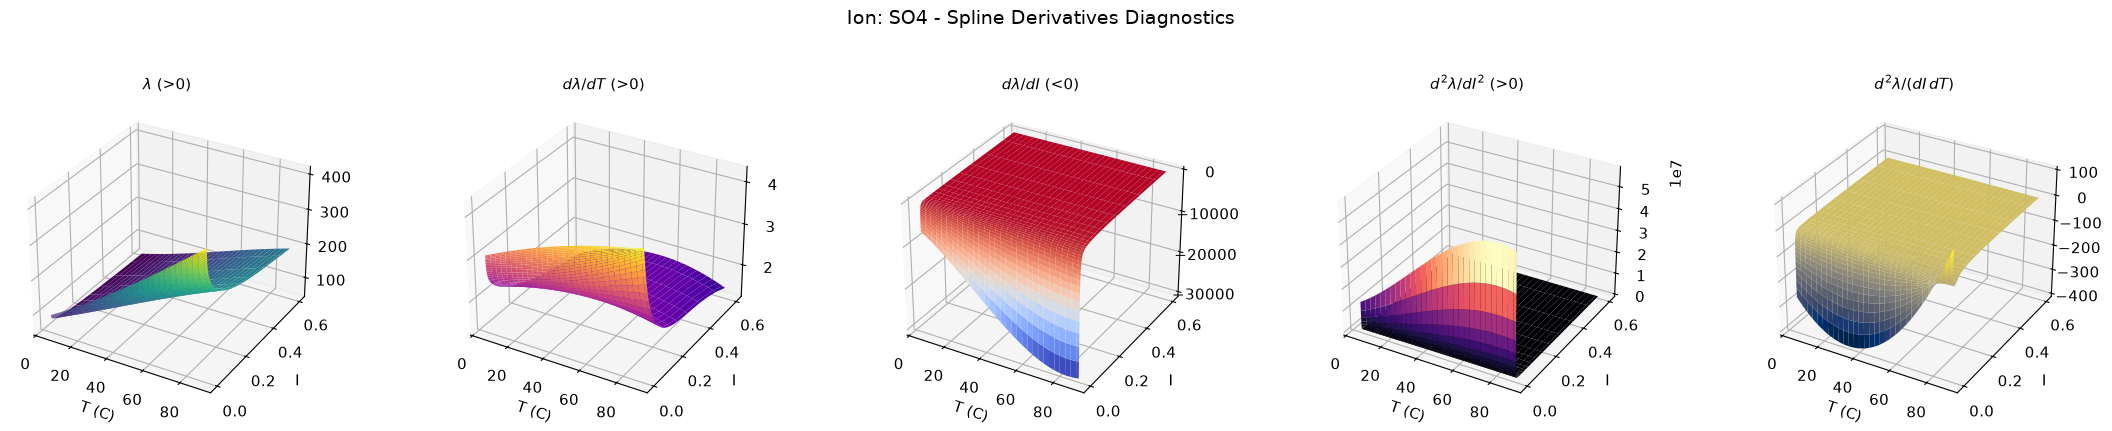


=== K2SO4 held-out (28 of 42 points in-hull) ===
spline additivity            n=28 RMSE=0.582 MAE=0.296 R2=0.9980 slope=1.037 | m>0.01: signed +2.9% MAD 2.9% max 5.8%
McCleskey Eq.8 (unspeciated) n=28 RMSE=0.433 MAE=0.211 R2=0.9989 slope=0.972 | m>0.01: signed -1.8% MAD 2.0% max 3.7%
spline residual structure: r(molality)=0.890, r(T)=-0.104


In [ ]:
# =====================================================================
# Cell 3 -- Derivative splines, physical inspection, McCleskey comparison
# Drop-in for the Colab pipeline. Assumes Cell 1 has produced, per ion,
# a RectBivariateSpline `sp` fit on (x, T) with x = I (current) or
# x = sqrt(I) (recommended, see SQRT_I flag), plus its bounding box.
# Standalone: rebuilds the chain from the CSV if run alone.
# =====================================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from scipy.stats import pearsonr

SQRT_I = True   # fit splines against sqrt(I) instead of I  <-- key switch
CSV = 'empirical_conductivity_library.csv'

# ---- McCleskey (2011) Table 1, lam = lam0(T) - A(T)*sqrt(I)/(1+B*sqrt(I))
# all quadratic coefficients positive (verified against limiting
# conductivities at 25 C and against the raw electrolyte data)
MC = {
 'K':  ((0.003046,1.261,40.70),(0.00535,0.9316,22.59),1.5),
 'Na': ((0.003763,0.8770,26.23),(0.00027,1.141,32.07),1.7),
 'Mg': ((0.01068,1.695,57.16),(0.02453,1.915,80.50),2.1),
 'SO4':((0.01037,2.838,82.37),(0.03324,5.889,193.5),2.6),
 'Cl': ((0.003817,1.337,40.99),(0.00613,0.9469,22.01),1.5),
}
def mccleskey_lambda(ion, I, T, dI=False):
    (a,b,c),(p,q,r),B = MC[ion]
    T = np.asarray(T, float); I = np.asarray(I, float); s = np.sqrt(I)
    A = p*T**2 + q*T + r
    if dI:                      # analytic d(lambda)/dI, always negative
        return -A/(2*s*(1+B*s)**2)
    return (a*T**2 + b*T + c) - A*s/(1+B*s)

# ---------- rebuild deconvolution chain ----------
df = pd.read_csv(CSV)
d  = df[df.Pressure_MPa == 0.1].copy()
def salt(name, f):
    s = d[d.Salt == name].copy()
    s['I'] = f*s.Molality_molkg
    s['Lam'] = s.Conductivity_mScm/s.Molality_molkg
    return s
kcl, nacl, mgcl2, na2so4, k2so4 = salt('KCl',1), salt('NaCl',1), salt('MgCl2',3), salt('Na2SO4',3), salt('K2SO4',3)

tK = mccleskey_lambda('K', kcl.I, kcl.Temperature_C) / (
     mccleskey_lambda('K', kcl.I, kcl.Temperature_C) + mccleskey_lambda('Cl', kcl.I, kcl.Temperature_C))
kcl['lam_K'], kcl['lam_Cl'] = tK*kcl.Lam, (1-tK)*kcl.Lam

class IonSpline:
    """RectBivariateSpline wrapper; handles the sqrt(I) coordinate and
    chain-rule conversion of derivatives back to d/dI."""
    def __init__(self, sub, col):
        Iv = np.sort(sub.I.unique()); Tv = np.sort(sub.Temperature_C.unique())
        Z  = sub.pivot_table(index='I', columns='Temperature_C', values=col).loc[Iv, Tv].values
        n  = Z.size
        x  = np.sqrt(Iv) if SQRT_I else Iv
        self.sp = RectBivariateSpline(x, Tv, Z, kx=3, ky=3, s=n - np.sqrt(2*n))
        self.bb = (Iv.min(), Iv.max(), Tv.min(), Tv.max())
        self.train = (Iv, Tv, Z)
    def _x(self, I): return np.sqrt(I) if SQRT_I else np.asarray(I, float)
    def inhull(self, I, T):
        b = self.bb; return (I >= b[0]) & (I <= b[1]) & (T >= b[2]) & (T <= b[3])
    def ev(self, I, T): return self.sp.ev(self._x(I), T)
    def ev_or_nan(self, I, T):
        out = self.ev(I, T); return np.where(self.inhull(np.asarray(I), np.asarray(T)), out, np.nan)
    def dT(self, I, T): return self.sp.ev(self._x(I), T, dy=1)
    def dI(self, I, T):
        g = self.sp.ev(self._x(I), T, dx=1)
        return g/(2*np.sqrt(I)) if SQRT_I else g       # chain rule
    def d2I(self, I, T):
        if not SQRT_I: return self.sp.ev(self._x(I), T, dx=2)
        u = np.sqrt(I)
        return self.sp.ev(u, T, dx=2)/(4*I) - self.sp.ev(u, T, dx=1)/(4*I*u)
    def dIdT(self, I, T):
        g = self.sp.ev(self._x(I), T, dx=1, dy=1)
        return g/(2*np.sqrt(I)) if SQRT_I else g       # cross derivative chain rule

ion = {}
ion['K']  = IonSpline(kcl, 'lam_K');  ion['Cl'] = IonSpline(kcl, 'lam_Cl')
nacl = nacl[ion['Cl'].inhull(nacl.I, nacl.Temperature_C)].copy()
nacl['lam_Na'] = nacl.Lam - ion['Cl'].ev(nacl.I, nacl.Temperature_C)
ion['Na'] = IonSpline(nacl, 'lam_Na')
mgcl2 = mgcl2[ion['Cl'].inhull(mgcl2.I, mgcl2.Temperature_C)].copy()
mgcl2['lam_Mg'] = mgcl2.Lam - 2*ion['Cl'].ev(mgcl2.I, mgcl2.Temperature_C)
ion['Mg'] = IonSpline(mgcl2, 'lam_Mg')
na2so4 = na2so4[ion['Na'].inhull(na2so4.I, na2so4.Temperature_C)].copy()
na2so4['lam_SO4'] = na2so4.Lam - 2*ion['Na'].ev(na2so4.I, na2so4.Temperature_C)
ion['SO4'] = IonSpline(na2so4, 'lam_SO4')

# ---------- physical inspection of derivatives ----------
print('=== derivative diagnostics (dense grid inside each ion hull) ===')
rows = []
for name, s in ion.items():
    b = s.bb
    Ig = np.geomspace(b[0], b[1], 200); Tg = np.linspace(b[2], b[3], 100)
    II, TT = np.meshgrid(Ig, Tg, indexing='ij')
    lam, dT, dI, d2 = s.ev(II,TT), s.dT(II,TT), s.dI(II,TT), s.d2I(II,TT)
    tc = dT/lam*100
    rows.append([name, lam.min(), (lam < 0).mean()*100, (dT > 0).mean()*100,
                 np.percentile(tc,1), np.percentile(tc,99), (dI < 0).mean()*100, (d2 > 0).mean()*100])
print(pd.DataFrame(rows, columns=['ion','lam_min','%lam<0','%dT>0','tcoef_p1 (%/C)','tcoef_p99 (%/C)','%dI<0','%d2I>0']).round(2).to_string(index=False))
print('physics requires: lam>0, dT>0 (approx 1-3 %/C), dI<0, d2I>0 everywhere')

# ---------- plot derivative splines ----------
print('\n=== Plotting derivative diagnostic surfaces ===')
for name, s in ion.items():
    b = s.bb
    # Plotting grid (slightly lower res for responsive 3D rendering)
    Tg, Ig = np.meshgrid(np.linspace(b[2], b[3], 60), np.geomspace(b[0], b[1], 60))

    lam_plot = s.ev(Ig, Tg)
    dT_plot = s.dT(Ig, Tg)
    dI_plot = s.dI(Ig, Tg)
    d2_plot = s.d2I(Ig, Tg)
    dIdT_plot = s.dIdT(Ig, Tg)

    # Increased width to 22 to accommodate the 5th plot
    fig = plt.figure(figsize=(22, 4))
    fig.suptitle(f'Ion: {name} - Spline Derivatives Diagnostics', fontsize=14, y=1.05)

    ax1 = fig.add_subplot(151, projection='3d')
    ax1.plot_surface(Tg, Ig, lam_plot, cmap='viridis', edgecolor='none')
    ax1.set_title('$\lambda$ (>0)')
    ax1.set_xlabel('T (C)'); ax1.set_ylabel('I')

    ax2 = fig.add_subplot(152, projection='3d')
    ax2.plot_surface(Tg, Ig, dT_plot, cmap='plasma', edgecolor='none')
    ax2.set_title('$d\lambda/dT$ (>0)')
    ax2.set_xlabel('T (C)'); ax2.set_ylabel('I')

    ax3 = fig.add_subplot(153, projection='3d')
    ax3.plot_surface(Tg, Ig, dI_plot, cmap='coolwarm', edgecolor='none')
    ax3.set_title('$d\lambda/dI$ (<0)')
    ax3.set_xlabel('T (C)'); ax3.set_ylabel('I')

    ax4 = fig.add_subplot(154, projection='3d')
    ax4.plot_surface(Tg, Ig, d2_plot, cmap='magma', edgecolor='none')
    ax4.set_title('$d^2\lambda/dI^2$ (>0)')
    ax4.set_xlabel('T (C)'); ax4.set_ylabel('I')

    ax5 = fig.add_subplot(155, projection='3d')
    ax5.plot_surface(Tg, Ig, dIdT_plot, cmap='cividis', edgecolor='none')
    ax5.set_title('$d^2\lambda/(dI\,dT)$')
    ax5.set_xlabel('T (C)'); ax5.set_ylabel('I')

    plt.tight_layout()

    # Save files to Colab working directory
    plt.savefig(f'{name}_derivatives_diagnostic.pdf', bbox_inches='tight')
    plt.savefig(f'{name}_derivatives_diagnostic.png', bbox_inches='tight', dpi=300)

    plt.show()

# ---------- K2SO4 held-out validation + McCleskey comparison ----------
ok = ion['K'].inhull(k2so4.I, k2so4.Temperature_C) & ion['SO4'].inhull(k2so4.I, k2so4.Temperature_C)
v = k2so4[ok].copy()
v['pred_spline'] = (2*ion['K'].ev(v.I, v.Temperature_C) + ion['SO4'].ev(v.I, v.Temperature_C))*v.Molality_molkg
v['pred_mc']     = (2*mccleskey_lambda('K', v.I, v.Temperature_C)
                    +  mccleskey_lambda('SO4', v.I, v.Temperature_C))*v.Molality_molkg

def report(y, p, m, label):
    r = p - y; keep = m > 0.01
    sd = (p[keep] - y[keep])/y[keep]*100
    sl, _ = np.polyfit(y, p, 1)
    R2 = 1 - np.sum(r**2)/np.sum((y - y.mean())**2)
    print('%-28s n=%d RMSE=%.3f MAE=%.3f R2=%.4f slope=%.3f | m>0.01: signed %+.1f%% MAD %.1f%% max %.1f%%' %
          (label, len(y), np.sqrt((r**2).mean()), np.abs(r).mean(), R2, sl, sd.mean(), np.abs(sd).mean(), np.abs(sd).max()))
print('\n=== K2SO4 held-out (%d of 42 points in-hull) ===' % len(v))
report(v.Conductivity_mScm.values, v.pred_spline.values, v.Molality_molkg.values, 'spline additivity')
report(v.Conductivity_mScm.values, v.pred_mc.values,     v.Molality_molkg.values, 'McCleskey Eq.8 (unspeciated)')
hi = v[v.Molality_molkg > 0.01]
sd = (hi.pred_spline - hi.Conductivity_mScm)/hi.Conductivity_mScm*100
print('spline residual structure: r(molality)=%.3f, r(T)=%.3f' %
      (pearsonr(hi.Molality_molkg, sd)[0], pearsonr(hi.Temperature_C, sd)[0]))

code cell 4 - comparison of my model against mccleskey

   K2SO4 HELD-OUT BENCHMARK  (n = 28, pct stats on m > 0.01: n = 14)
Metric                      Your framework        McCleskey (2011)      
------------------------------------------------------------------------
R2 vs 1:1                   0.99801               0.99891               
RMSE (mS/cm)                0.5841                0.4327                
MAE (mS/cm)                 0.2968                0.2106                
Best-fit slope              1.0374                0.9716                
Mean signed dev (%)         +2.89                 -1.79                 
Mean abs dev (%)            2.89                  2.01                  
Max abs dev (%)             5.61                  3.68                  
------------------------------------------------------------------------
TARGET: framework trails McCleskey by 0.1514 mS/cm RMSE. Keep tuning Cell 1.
Residual correlations (m > 0.01):
  yours:     r(molality) = +0.885   r(T) = -0.098
  McCleskey: r(molality) = -0.854   r(T)

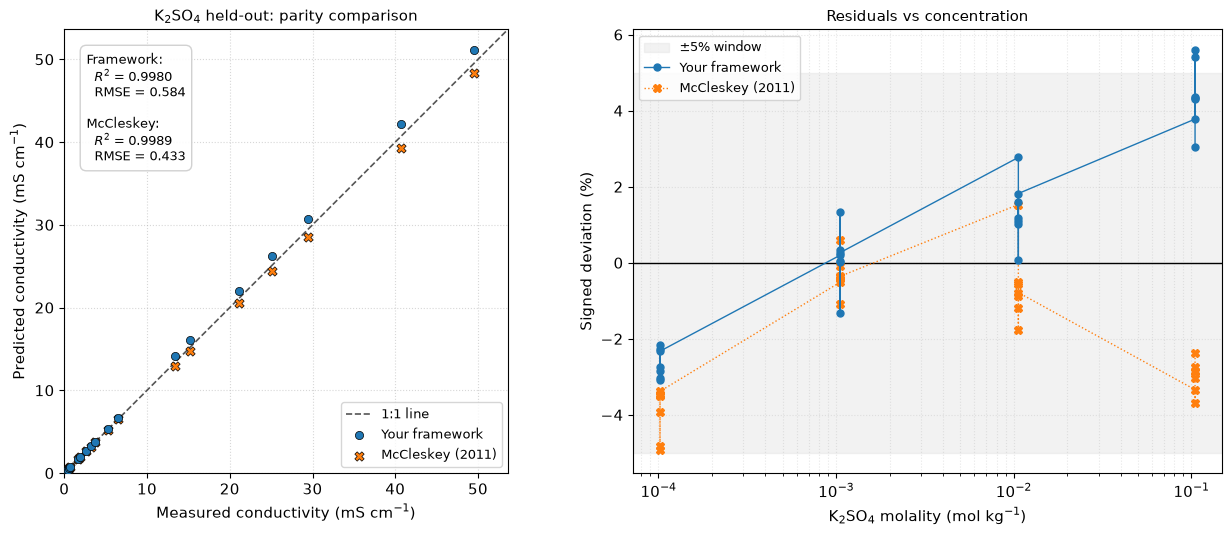

In [ ]:
# ==========================================================
# CELL 4 - PERMANENT VALIDATION ARENA: FRAMEWORK VS MCCLESKEY
# Reusable benchmark. Depends only on what Cell 2 leaves in memory,
# so it keeps working as Cell 1 evolves.
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sstats

# 1. Pipeline and state validation
for _required in ('k2so4_usable', 'Z_yours_at_k2so4', 'Z_k2so4_real',
                  'T_k2so4', 'M_k2so4', 'I_k2so4', 'save_fig'):
    if _required not in globals():
        raise NameError(f"Missing '{_required}' in memory. Run Cells 1 and 2 first.")

PCT_STABLE_MOLALITY = 0.01  # same threshold as Cell 2

# ==========================================================
# 2. McCLESKEY (2011) MODEL - Table 1, actual published form
#    lam_i(T, I) = lam0_i(T) - A_i(T) * sqrt(I) / (1 + B_i * sqrt(I))
#    lam0(T) = a*T^2 + b*T + c
#    A(T)    = p*T^2 + q*T + r
#    T in degrees Celsius, I = ionic strength (mol/kg)
#    kappa_salt = sum_i nu_i * m_salt * lam_i
# ==========================================================
MC_COEFFS = {
    #        lam0: (a, b, c)              A: (p, q, r)               B
    'K':   ((0.003046, 1.261,  40.70), (0.00535, 0.9316, 22.59), 1.5),
    'Na':  ((0.003763, 0.8770, 26.23), (0.00027, 1.141,  32.07), 1.7),
    'Mg':  ((0.01068,  1.695,  57.16), (0.02453, 1.915,  80.50), 2.1),
    'SO4': ((0.01037,  2.838,  82.37), (0.03324, 5.889,  193.5), 2.6),
    'Cl':  ((0.003817, 1.337,  40.99), (0.00613, 0.9469, 22.01), 1.5),
}

def mccleskey_lambda(ion, I, T_C):
    """Ionic molar conductivity lam_i(T, I) per McCleskey (2011) Table 1."""
    (a, b, c), (p, q, r), B = MC_COEFFS[ion]
    T_C = np.asarray(T_C, dtype=float)
    sqrt_I = np.sqrt(np.asarray(I, dtype=float))
    lam0 = a * T_C**2 + b * T_C + c
    A = p * T_C**2 + q * T_C + r
    return lam0 - A * sqrt_I / (1.0 + B * sqrt_I)

def mccleskey_kappa_k2so4(T_K, molality, I):
    """Specific conductivity (mS/cm) of K2SO4 via ionic additivity:
    kappa = m * (2*lam_K + lam_SO4), evaluated at the solution's I."""
    T_C = np.asarray(T_K, dtype=float) - 273.15
    lam_K = mccleskey_lambda('K', I, T_C)
    lam_SO4 = mccleskey_lambda('SO4', I, T_C)
    return np.asarray(molality, dtype=float) * (2.0 * lam_K + lam_SO4)

# ==========================================================
# 3. STATISTICAL SCORING ENGINE
# ==========================================================
def compute_metrics(real, predicted, molality, stable_threshold=PCT_STABLE_MOLALITY):
    real = np.asarray(real, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    molality = np.asarray(molality, dtype=float)
    resid = predicted - real

    rmse = np.sqrt(np.mean(resid**2))
    mae = np.mean(np.abs(resid))
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((real - real.mean())**2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    slope, intercept = np.polyfit(real, predicted, 1)

    # percent metrics only where kappa is not vanishingly small
    stable = molality > stable_threshold
    pct = 100.0 * resid[stable] / real[stable]
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'slope': slope,
            'bias_pct': pct.mean(), 'mad_pct': np.abs(pct).mean(),
            'max_pct': np.abs(pct).max(), 'n': len(real), 'n_stable': stable.sum()}

# ==========================================================
# 4. HEAD-TO-HEAD RUN
# ==========================================================
Z_framework = np.asarray(Z_yours_at_k2so4, dtype=float)
Z_mccleskey = mccleskey_kappa_k2so4(T_k2so4, M_k2so4, I_k2so4)

m_yours = compute_metrics(Z_k2so4_real, Z_framework, M_k2so4)
m_mcc = compute_metrics(Z_k2so4_real, Z_mccleskey, M_k2so4)

print("=" * 72)
print(f"   K2SO4 HELD-OUT BENCHMARK  (n = {m_yours['n']}, "
      f"pct stats on m > {PCT_STABLE_MOLALITY}: n = {m_yours['n_stable']})")
print("=" * 72)
print(f"{'Metric':<28}{'Your framework':<22}{'McCleskey (2011)':<22}")
print("-" * 72)
print(f"{'R2 vs 1:1':<28}{m_yours['r2']:<22.5f}{m_mcc['r2']:<22.5f}")
print(f"{'RMSE (mS/cm)':<28}{m_yours['rmse']:<22.4f}{m_mcc['rmse']:<22.4f}")
print(f"{'MAE (mS/cm)':<28}{m_yours['mae']:<22.4f}{m_mcc['mae']:<22.4f}")
print(f"{'Best-fit slope':<28}{m_yours['slope']:<22.4f}{m_mcc['slope']:<22.4f}")
print(f"{'Mean signed dev (%)':<28}{m_yours['bias_pct']:<+22.2f}{m_mcc['bias_pct']:<+22.2f}")
print(f"{'Mean abs dev (%)':<28}{m_yours['mad_pct']:<22.2f}{m_mcc['mad_pct']:<22.2f}")
print(f"{'Max abs dev (%)':<28}{m_yours['max_pct']:<22.2f}{m_mcc['max_pct']:<22.2f}")
print("-" * 72)
if m_yours['rmse'] < m_mcc['rmse']:
    print(f"SUCCESS: framework beats McCleskey by "
          f"{m_mcc['rmse'] - m_yours['rmse']:.4f} mS/cm RMSE on this dataset.")
else:
    print(f"TARGET: framework trails McCleskey by "
          f"{m_yours['rmse'] - m_mcc['rmse']:.4f} mS/cm RMSE. Keep tuning Cell 1.")
print("=" * 72)

# residual structure of both models
stable = M_k2so4 > PCT_STABLE_MOLALITY
dev_yours = 100.0 * (Z_framework - Z_k2so4_real) / Z_k2so4_real
dev_mcc = 100.0 * (Z_mccleskey - Z_k2so4_real) / Z_k2so4_real
if stable.sum() > 3:
    r_m_y, _ = sstats.pearsonr(M_k2so4[stable], dev_yours[stable])
    r_t_y, _ = sstats.pearsonr(T_k2so4[stable], dev_yours[stable])
    r_m_m, _ = sstats.pearsonr(M_k2so4[stable], dev_mcc[stable])
    r_t_m, _ = sstats.pearsonr(T_k2so4[stable], dev_mcc[stable])
    print(f"Residual correlations (m > {PCT_STABLE_MOLALITY}):")
    print(f"  yours:     r(molality) = {r_m_y:+.3f}   r(T) = {r_t_y:+.3f}")
    print(f"  McCleskey: r(molality) = {r_m_m:+.3f}   r(T) = {r_t_m:+.3f}")

# ==========================================================
# 5. FIGURES
# ==========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Plot A: parity
max_limit = max(Z_k2so4_real.max(), Z_framework.max(), Z_mccleskey.max()) * 1.05
lims = [0, max_limit]
ax1.plot(lims, lims, ls='--', color='#555555', lw=1.2, label='1:1 line')
ax1.scatter(Z_k2so4_real, Z_framework, color='#1f77b4', marker='o', s=35,
            edgecolors='black', linewidths=0.5, label='Your framework', zorder=4)
ax1.scatter(Z_k2so4_real, Z_mccleskey, color='#ff7f0e', marker='X', s=45,
            edgecolors='black', linewidths=0.5, label='McCleskey (2011)', zorder=3)
box = (f"Framework:\n  $R^2$ = {m_yours['r2']:.4f}\n  RMSE = {m_yours['rmse']:.3f}\n\n"
       f"McCleskey:\n  $R^2$ = {m_mcc['r2']:.4f}\n  RMSE = {m_mcc['rmse']:.3f}")
ax1.text(0.05, 0.95, box, transform=ax1.transAxes, va='top', ha='left', fontsize=9,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#cccccc', alpha=0.9))
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel(r'Measured conductivity (mS cm$^{-1}$)')
ax1.set_ylabel(r'Predicted conductivity (mS cm$^{-1}$)')
ax1.set_title(r'K$_2$SO$_4$ held-out: parity comparison')
ax1.set_aspect('equal')
ax1.legend(loc='lower right')
ax1.grid(True, linestyle=':', alpha=0.5)

# Plot B: residuals vs molality
ax2.axhspan(-5, 5, color='#e0e0e0', alpha=0.4, label=r'$\pm$5% window')
order = np.argsort(M_k2so4)
ax2.plot(M_k2so4[order], dev_yours[order], color='#1f77b4', marker='o', ls='-',
         lw=1, ms=5, label='Your framework', zorder=4)
ax2.plot(M_k2so4[order], dev_mcc[order], color='#ff7f0e', marker='X', ls=':',
         lw=1, ms=6, label='McCleskey (2011)', zorder=3)
ax2.axhline(0, color='black', lw=1.0)
ax2.set_xscale('log')
ax2.set_xlabel(r'K$_2$SO$_4$ molality (mol kg$^{-1}$)')
ax2.set_ylabel('Signed deviation (%)')
ax2.set_title('Residuals vs concentration')
ax2.legend(loc='best')
ax2.grid(True, which='both', linestyle=':', alpha=0.3)

plt.tight_layout()
save_fig(fig, 'framework_vs_mccleskey_head_to_head')
plt.show()

code that downloads all pdfs from figures folder

In [ ]:
from google.colab import files
!rm -f /content/figs.zip
!zip -j /content/figs.zip /content/Figures/*.pdf /content/*.pdf
files.download('/content/figs.zip')

  adding: framework_vs_mccleskey_head_to_head.pdf (deflated 29%)
  adding: ionic_surfaces.pdf (deflated 3%)
  adding: ion_surface_Clminus.pdf (deflated 8%)
  adding: ion_surface_Kplus.pdf (deflated 8%)
  adding: ion_surface_Mg2plus.pdf (deflated 8%)
  adding: ion_surface_Naplus.pdf (deflated 8%)
  adding: ion_surface_SO42minus.pdf (deflated 8%)
  adding: k2so4_deviation_histogram.pdf (deflated 28%)
  adding: k2so4_deviation_map.pdf (deflated 27%)
  adding: k2so4_deviation_vs_molality.pdf (deflated 31%)
  adding: k2so4_deviation_vs_temperature.pdf (deflated 28%)
  adding: k2so4_isotherms.pdf (deflated 32%)
  adding: k2so4_parity.pdf (deflated 33%)
  adding: Cl_derivatives_diagnostic.pdf (deflated 3%)
  adding: K_derivatives_diagnostic.pdf (deflated 3%)
  adding: Mg_derivatives_diagnostic.pdf (deflated 3%)
  adding: Na_derivatives_diagnostic.pdf (deflated 3%)
  adding: SO4_derivatives_diagnostic.pdf (deflated 3%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

validation code to make sure mccleskey was implemented correctly

In [ ]:
# ==========================================================
# ONE-OFF CHECK: does our McCleskey implementation reproduce
# the McCleskey (2011) dataset itself? (paper reports ~0.1%
# mean deviation for his own fits, so expect ~0.1-1% here)
# Run after Cell 4 (needs mccleskey_lambda) or standalone
# with the MC_COEFFS block pasted in.
# ==========================================================
import numpy as np
import pandas as pd

df = pd.read_csv('empirical_conductivity_library.csv')
d = df[df['Pressure_MPa'] == 0.1].copy()

STOICH = {
    'KCl':    {'K': 1, 'Cl': 1},
    'NaCl':   {'Na': 1, 'Cl': 1},
    'MgCl2':  {'Mg': 1, 'Cl': 2},
    'Na2SO4': {'Na': 2, 'SO4': 1},
    'K2SO4':  {'K': 2, 'SO4': 1},
}
I_FACTOR = {'KCl': 1.0, 'NaCl': 1.0, 'MgCl2': 3.0, 'Na2SO4': 3.0, 'K2SO4': 3.0}

print(f"{'Salt':<8}{'n':>5}{'mean |dev| %':>14}{'mean signed %':>15}{'max |dev| %':>13}")
print('-' * 55)
all_dev = []
for salt, stoich in STOICH.items():
    s = d[d['Salt'] == salt]
    s = s[s['Molality_molkg'] > 0.001]  # avoid pct blow-up at trace levels
    m = s['Molality_molkg'].values
    T_C = s['Temperature_C'].values
    I = m * I_FACTOR[salt]
    kappa_pred = m * sum(nu * mccleskey_lambda(ion, I, T_C) for ion, nu in stoich.items())
    dev = 100.0 * (kappa_pred - s['Conductivity_mScm'].values) / s['Conductivity_mScm'].values
    all_dev.append(dev)
    print(f"{salt:<8}{len(s):>5}{np.abs(dev).mean():>14.2f}{dev.mean():>+15.2f}{np.abs(dev).max():>13.2f}")

all_dev = np.concatenate(all_dev)
print('-' * 55)
print(f"{'ALL':<8}{len(all_dev):>5}{np.abs(all_dev).mean():>14.2f}{all_dev.mean():>+15.2f}{np.abs(all_dev).max():>13.2f}")
print("\nPASS criterion: overall mean |dev| around 0.1-1% -> implementation")
print("matches the published McCleskey (2011) method that generated this data.")


Salt        n  mean |dev| %  mean signed %  max |dev| %
-------------------------------------------------------
KCl        28          1.33          +0.48         3.18
NaCl       28          1.38          -0.99         3.12
MgCl2      21          7.77          +7.77        15.09
Na2SO4     28          7.50          -6.95        14.43
K2SO4      35          1.96          -1.84         4.94
-------------------------------------------------------
ALL       140          3.70          -0.79        15.09

PASS criterion: overall mean |dev| around 0.1-1% -> implementation
matches the published McCleskey (2011) method that generated this data.


updating cvs with leila's data

In [ ]:
import pandas as pd
import io

# 1. The parsed and cleaned data from Mahboub's Table S2 (converted to mS/cm and Celsius)
leila_new_data_csv = """Salt,Source,Source_Type,Temperature_C,Pressure_MPa,Molality_molkg,Concentration_molL,Conductivity_mScm,Notes
NaCl,Mahboub,experimental,-10.0,0.1,0.1711,,7.8520,
NaCl,Mahboub,experimental,-6.0,0.1,0.1711,,8.6490,
NaCl,Mahboub,experimental,-3.0,0.1,0.1711,,9.8230,
NaCl,Mahboub,experimental,-1.0,0.1,0.1711,,9.8470,
NaCl,Mahboub,experimental,5.0,0.1,0.1711,,11.8290,
NaCl,Mahboub,experimental,20.0,0.1,0.1711,,16.1130,
NaCl,Mahboub,experimental,25.0,0.1,0.1711,,17.7270,
NaCl,Mahboub,experimental,-10.0,0.1,0.5133,,21.7430,
NaCl,Mahboub,experimental,-6.0,0.1,0.5133,,23.5330,
NaCl,Mahboub,experimental,-3.0,0.1,0.5133,,25.0500,
NaCl,Mahboub,experimental,-1.0,0.1,0.5133,,26.9900,
NaCl,Mahboub,experimental,5.0,0.1,0.5133,,31.3430,
NaCl,Mahboub,experimental,20.0,0.1,0.5133,,44.3070,
NaCl,Mahboub,experimental,25.0,0.1,0.5133,,48.7370,
NaCl,Mahboub,experimental,-10.0,0.1,0.8556,,31.8200,
NaCl,Mahboub,experimental,-6.0,0.1,0.8556,,35.4870,
NaCl,Mahboub,experimental,-3.0,0.1,0.8556,,39.4400,
NaCl,Mahboub,experimental,-1.0,0.1,0.8556,,41.1370,
NaCl,Mahboub,experimental,5.0,0.1,0.8556,,48.5170,
NaCl,Mahboub,experimental,20.0,0.1,0.8556,,68.4300,
NaCl,Mahboub,experimental,25.0,0.1,0.8556,,75.2730,
NaCl,Mahboub,experimental,-10.0,0.1,1.2834,,44.5070,
NaCl,Mahboub,experimental,-6.0,0.1,1.2834,,51.1400,
NaCl,Mahboub,experimental,-3.0,0.1,1.2834,,54.7930,
NaCl,Mahboub,experimental,-1.0,0.1,1.2834,,56.9530,
NaCl,Mahboub,experimental,5.0,0.1,1.2834,,68.4030,
NaCl,Mahboub,experimental,20.0,0.1,1.2834,,95.8000,
NaCl,Mahboub,experimental,25.0,0.1,1.2834,,105.3800,
NaCl,Mahboub,experimental,-10.0,0.1,1.7112,,57.4700,
NaCl,Mahboub,experimental,-6.0,0.1,1.7112,,63.8170,
NaCl,Mahboub,experimental,-3.0,0.1,1.7112,,70.0600,
NaCl,Mahboub,experimental,-1.0,0.1,1.7112,,71.9300,
NaCl,Mahboub,experimental,5.0,0.1,1.7112,,86.6530,
NaCl,Mahboub,experimental,20.0,0.1,1.7112,,120.5000,
NaCl,Mahboub,experimental,25.0,0.1,1.7112,,132.5500,
NaCl,Mahboub,experimental,-10.0,0.1,2.5667,,76.6400,
NaCl,Mahboub,experimental,-6.0,0.1,2.5667,,85.2000,
NaCl,Mahboub,experimental,-3.0,0.1,2.5667,,92.3130,
NaCl,Mahboub,experimental,-1.0,0.1,2.5667,,95.4500,
NaCl,Mahboub,experimental,5.0,0.1,2.5667,,113.4000,
NaCl,Mahboub,experimental,20.0,0.1,2.5667,,160.0330,
NaCl,Mahboub,experimental,25.0,0.1,2.5667,,176.0370,
NH4Cl,Mahboub,experimental,-10.0,0.1,0.187,,9.7410,
NH4Cl,Mahboub,experimental,-6.0,0.1,0.187,,11.8770,
NH4Cl,Mahboub,experimental,-3.0,0.1,0.187,,12.6030,
NH4Cl,Mahboub,experimental,-1.0,0.1,0.187,,13.3430,
NH4Cl,Mahboub,experimental,5.0,0.1,0.187,,15.4930,
NH4Cl,Mahboub,experimental,20.0,0.1,0.187,,21.1600,
NH4Cl,Mahboub,experimental,25.0,0.1,0.187,,23.2760,
NH4Cl,Mahboub,experimental,-10.0,0.1,0.9348,,47.5170,
NH4Cl,Mahboub,experimental,-6.0,0.1,0.9348,,52.7100,
NH4Cl,Mahboub,experimental,-3.0,0.1,0.9348,,55.8570,
NH4Cl,Mahboub,experimental,-1.0,0.1,0.9348,,59.8270,
NH4Cl,Mahboub,experimental,5.0,0.1,0.9348,,69.0870,
NH4Cl,Mahboub,experimental,20.0,0.1,0.9348,,94.3270,
NH4Cl,Mahboub,experimental,25.0,0.1,0.9348,,103.7590,
NH4Cl,Mahboub,experimental,-10.0,0.1,1.4021,,69.4200,
NH4Cl,Mahboub,experimental,-6.0,0.1,1.4021,,76.3870,
NH4Cl,Mahboub,experimental,-3.0,0.1,1.4021,,82.2800,
NH4Cl,Mahboub,experimental,-1.0,0.1,1.4021,,86.0270,
NH4Cl,Mahboub,experimental,5.0,0.1,1.4021,,99.7130,
NH4Cl,Mahboub,experimental,20.0,0.1,1.4021,,135.0000,
NH4Cl,Mahboub,experimental,25.0,0.1,1.4021,,148.5000,
NH4Cl,Mahboub,experimental,-10.0,0.1,1.8005,,90.3400,
NH4Cl,Mahboub,experimental,-6.0,0.1,1.8005,,99.2200,
NH4Cl,Mahboub,experimental,-3.0,0.1,1.8005,,106.4000,
NH4Cl,Mahboub,experimental,-1.0,0.1,1.8005,,112.6430,
NH4Cl,Mahboub,experimental,5.0,0.1,1.8005,,130.5330,
NH4Cl,Mahboub,experimental,20.0,0.1,1.8005,,173.8670,
NH4Cl,Mahboub,experimental,25.0,0.1,1.8005,,191.2530,
Na2CO3,Mahboub,experimental,-6.0,0.1,0.0472,,3.7860,
Na2CO3,Mahboub,experimental,-3.0,0.1,0.0472,,6.1990,
Na2CO3,Mahboub,experimental,-1.0,0.1,0.0472,,6.5500,
Na2CO3,Mahboub,experimental,5.0,0.1,0.0472,,5.1430,
Na2CO3,Mahboub,experimental,20.0,0.1,0.0472,,7.4750,
Na2CO3,Mahboub,experimental,25.0,0.1,0.0472,,8.2220,
Na2CO3,Mahboub,experimental,-10.0,0.1,0.0943,,5.3290,
Na2CO3,Mahboub,experimental,-6.0,0.1,0.0943,,6.5480,
Na2CO3,Mahboub,experimental,-3.0,0.1,0.0943,,11.0380,
Na2CO3,Mahboub,experimental,-1.0,0.1,0.0943,,11.6670,
Na2CO3,Mahboub,experimental,5.0,0.1,0.0943,,9.1450,
Na2CO3,Mahboub,experimental,20.0,0.1,0.0943,,13.3230,
Na2CO3,Mahboub,experimental,25.0,0.1,0.0943,,14.6560,
Na2CO3,Mahboub,experimental,-10.0,0.1,0.2359,,11.1840,
Na2CO3,Mahboub,experimental,-6.0,0.1,0.2359,,14.0570,
Na2CO3,Mahboub,experimental,-3.0,0.1,0.2359,,23.5870,
Na2CO3,Mahboub,experimental,-1.0,0.1,0.2359,,24.5000,
Na2CO3,Mahboub,experimental,5.0,0.1,0.2359,,18.9730,
Na2CO3,Mahboub,experimental,20.0,0.1,0.2359,,27.9600,
Na2CO3,Mahboub,experimental,25.0,0.1,0.2359,,30.7560,
Na2CO3,Mahboub,experimental,-10.0,0.1,0.3774,,15.9590,
Na2CO3,Mahboub,experimental,-6.0,0.1,0.3774,,19.5670,
Na2CO3,Mahboub,experimental,-3.0,0.1,0.3774,,33.0860,
Na2CO3,Mahboub,experimental,-1.0,0.1,0.3774,,34.9420,
Na2CO3,Mahboub,experimental,5.0,0.1,0.3774,,26.7700,
Na2CO3,Mahboub,experimental,20.0,0.1,0.3774,,39.8970,
Na2CO3,Mahboub,experimental,25.0,0.1,0.3774,,43.8860,
Na2CO3,Mahboub,experimental,-6.0,0.1,0.5189,,24.1800,
Na2CO3,Mahboub,experimental,-3.0,0.1,0.5189,,11.1150,
Na2CO3,Mahboub,experimental,-1.0,0.1,0.5189,,43.4010,
Na2CO3,Mahboub,experimental,5.0,0.1,0.5189,,33.8670,
Na2CO3,Mahboub,experimental,20.0,0.1,0.5189,,49.5570,
Na2CO3,Mahboub,experimental,25.0,0.1,0.5189,,54.5120,
NaCl:MgSO4 (1:1),Mahboub,experimental,-10.0,0.1,0.05,,6.0650,
NaCl:MgSO4 (1:1),Mahboub,experimental,-1.0,0.1,0.05,,8.4410,
NaCl:MgSO4 (1:1),Mahboub,experimental,20.0,0.1,0.05,,13.7470,
NaCl:MgSO4 (1:1),Mahboub,experimental,25.0,0.1,0.05,,15.1230,
NaCl:MgSO4 (1:1),Mahboub,experimental,-10.0,0.1,0.1,,11.3550,
NaCl:MgSO4 (1:1),Mahboub,experimental,-1.0,0.1,0.1,,15.2270,
NaCl:MgSO4 (1:1),Mahboub,experimental,20.0,0.1,0.1,,24.5870,
NaCl:MgSO4 (1:1),Mahboub,experimental,25.0,0.1,0.1,,27.0450,
NaCl:MgSO4 (1:1),Mahboub,experimental,-10.0,0.1,0.4,,32.8870,
NaCl:MgSO4 (1:1),Mahboub,experimental,-1.0,0.1,0.4,,40.2900,
NaCl:MgSO4 (1:1),Mahboub,experimental,20.0,0.1,0.4,,66.8270,
NaCl:MgSO4 (1:1),Mahboub,experimental,25.0,0.1,0.4,,73.5090,
NaCl:MgSO4 (1:1),Mahboub,experimental,-10.0,0.1,0.7,,30.8700,
NaCl:MgSO4 (1:1),Mahboub,experimental,-1.0,0.1,0.7,,35.7530,
NaCl:MgSO4 (1:1),Mahboub,experimental,20.0,0.1,0.7,,58.8200,
NaCl:MgSO4 (1:1),Mahboub,experimental,25.0,0.1,0.7,,64.7020,"""

# Load your existing library
df = pd.read_csv('empirical_conductivity_library.csv')

# 2. Fix existing Mahboub MgSO4 data (Converting S/m -> mS/cm)
# Checking if it's Mahboub's data and if it hasn't been converted yet
mahboub_mask = (df['Source'] == 'Mahboub') & (df['Salt'] == 'MgSO4')
if mahboub_mask.any():
    # Only scale it up if it looks suspiciously low (S/m instead of mS/cm)
    # The max value in S/m was ~5.8. Multiplied by 10 it should be ~58.
    if df.loc[mahboub_mask, 'Conductivity_mScm'].max() < 10.0:
        df.loc[mahboub_mask, 'Conductivity_mScm'] = df.loc[mahboub_mask, 'Conductivity_mScm'] * 10.0
        print("Fixed units for existing Mahboub MgSO4 data (converted S/m to mS/cm).")

# 3. Append the newly parsed data
new_df = pd.read_csv(io.StringIO(leila_new_data_csv))
df_combined = pd.concat([df, new_df], ignore_index=True)

# 4. Save
output_filename = 'compiled_conductivity_library.csv'
df_combined.to_csv(output_filename, index=False)

print(f"Successfully compiled all data! Saved to {output_filename}")

Fixed units for existing Mahboub MgSO4 data (converted S/m to mS/cm).
Successfully compiled all data! Saved to compiled_conductivity_library.csv
